# ASR Hallucination Detection with Language-Model Uncertainty

This notebook studies a different hallucination-detection principle from the ASR-confidence notebook.

Main idea:
- take the ASR `pred_text`
- use a language model to measure how *surprising*, *uncertain*, or *unstable* that predicted text looks
- test whether those language-model uncertainty signals help detect `hallucination` vs `no_hallucination`
- evaluate detection quality with ROC and especially DET behavior

Why this notebook is useful:
- it gives you a **text-side baseline**
- it can be compared against your earlier **ASR-side uncertainty** notebook
- it helps answer a more focused question:

> Can transcript-level language-model uncertainty act as a useful proxy for hallucination detection?

Important limitation:
- this notebook does **not** directly compare the transcript to the audio at inference time
- so it does **not** measure semantic grounding directly
- instead, it tests whether hallucinated transcripts tend to look unusually uncertain or structurally odd from the perspective of a text language model

Recommended usage:
1. Run the notebook top to bottom.
2. Let it download or load your labeled CSV files.
3. Compute LM-based uncertainty features from `pred_text`.
4. Run the ablation study and DET analysis.
5. Use the summary tables and saved outputs in your final report.


## Workflow Overview

This notebook follows one continuous pipeline:

1. Load the labeled ASR CSV files.
2. Clean and merge the human hallucination labels.
3. Keep only rows with usable `pred_text`.
4. Use a pretrained text language model to compute uncertainty features.
5. Build a binary hallucination detector from those features.
6. Run a multi-ablation comparison.
7. Inspect ROC, DET, coefficients, and mistakes.

The goal is to keep the notebook readable even for someone seeing the project for the first time.


In [1]:
# Install lightweight dependencies used by the notebook.
# transformers is needed for language-model perplexity style features.
!pip -q install pandas numpy scikit-learn matplotlib seaborn requests transformers torch tqdm


## 1. Configuration

This section controls:
- where the labeled CSV files come from
- which language model is used for transcript uncertainty
- modeling settings such as test split and random seed

Default behavior:
- download CSV files from your GitHub repository
- use `distilgpt2` as a lightweight causal language model

Why `distilgpt2`?
- it is small enough to run comfortably in Colab
- it still provides useful next-token log-probability signals
- it is a practical first baseline for transcript-level uncertainty


In [2]:
from pathlib import Path

USE_GITHUB_REPO = True
GITHUB_OWNER = "GarimaTomar28"
GITHUB_REPO = "first-"
GITHUB_BRANCH = "main"

LOCAL_DATA_DIR = Path("lm_uncertainty_data")
LOCAL_DATA_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path("lm_uncertainty_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

LM_MODEL_NAME = "distilgpt2"

TEST_SIZE = 0.30
RANDOM_STATE = 42
MIN_ROWS_FOR_MODELING = 30
MAX_TEXT_CHARS = 600

print("Using GitHub repo:", USE_GITHUB_REPO)
print("Input directory:", LOCAL_DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("Language model:", LM_MODEL_NAME)


Using GitHub repo: True
Input directory: /content/lm_uncertainty_data
Output directory: /content/lm_uncertainty_outputs
Language model: distilgpt2


## 2. Download or discover labeled CSV files

This step gathers all candidate CSV files.

Why this is done automatically:
- it keeps the notebook easy to rerun
- it avoids manual upload every time
- later cells will automatically keep only the files that contain usable hallucination labels


In [3]:
import requests

downloaded_files = []

if USE_GITHUB_REPO:
    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents?ref={GITHUB_BRANCH}"
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    repo_items = resp.json()

    for item in repo_items:
        name = item["name"]
        if item["type"] == "file" and name.lower().endswith(".csv"):
            raw_url = item["download_url"]
            out_path = LOCAL_DATA_DIR / name
            file_resp = requests.get(raw_url, timeout=30)
            file_resp.raise_for_status()
            out_path.write_bytes(file_resp.content)
            downloaded_files.append(out_path)

    print("Downloaded CSV files:")
    for f in downloaded_files:
        print("-", f.name)
else:
    downloaded_files = sorted(LOCAL_DATA_DIR.glob("*.csv"))
    print("Using local CSV files:")
    for f in downloaded_files:
        print("-", f.name)


Downloaded CSV files:
- adversarial_labels (2).csv
- commonvoice_annotation_completed .csv
- librispeech_annotation_noisy.csv
- librispeech_labels.csv
- primock_medical_noisy_labels.csv


## 3. Load all candidate CSVs and keep usable labeled files

A file is considered usable if it contains at least one of:
- `hallucination_binary`
- `label_3class`

We also preserve the source filename so that later analyses can show which datasets contributed to the final merged set.


In [4]:
import pandas as pd

candidate_frames = []
load_report = []

for csv_path in sorted(LOCAL_DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(csv_path)
        cols = set(df.columns)
        usable = ("hallucination_binary" in cols) or ("label_3class" in cols)
        load_report.append({
            "file": csv_path.name,
            "rows": len(df),
            "usable_for_labels": usable,
            "columns": list(df.columns),
        })
        if usable:
            df["source_file"] = csv_path.name
            candidate_frames.append(df)
    except Exception as exc:
        load_report.append({
            "file": csv_path.name,
            "rows": None,
            "usable_for_labels": False,
            "columns": [f"ERROR: {exc}"],
        })

load_report_df = pd.DataFrame(load_report)
display(load_report_df[["file", "rows", "usable_for_labels"]])

if not candidate_frames:
    raise ValueError("No usable labeled CSV files were found.")

raw_df = pd.concat(candidate_frames, ignore_index=True)
print("Merged candidate rows:", len(raw_df))
raw_df.head()


,file,rows,usable_for_labels
0,adversarial_labels (2).csv,100,True
1,commonvoice_annotation_completed .csv,73,True
2,librispeech_annotation_noisy.csv,292,True
3,librispeech_labels.csv,100,True
4,primock_medical_noisy_labels.csv,100,True


Merged candidate rows: 665


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,annotator_id,notes,source_file,meeting_id,speaker,noise_type,snr_db,audio_path
0,adversarial,adv_2961-960-0003,THEY WERE ABSORBED IN HIS THEOLOGY AND WERE UN...,They were absorbed in theology and were under ...,1.000000,-0.489062,0.199341,1.514085,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
1,adversarial,adv_8555-284447-0017,WHEN THIS HAD BEEN ACCOMPLISHED THE BOOLOOROO ...,And he was one of the most popular victims in ...,1.000000,-1.302190,0.182588,1.000000,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
2,adversarial,adv_2300-131720-0005,WHY IF WE ERECT A STATION AT THE FALLS IT IS A...,"Why, if we erect a station at the falls, it is...",1.000000,-0.353160,0.072554,1.112500,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
3,adversarial,adv_5142-36377-0022,I WISH YOU GOOD NIGHT SHE LAID HER BONY HANDS ...,I wish you would. Today we're going to hand th...,0.977273,-0.921636,0.340546,1.476510,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
4,adversarial,adv_8455-210777-0040,THEN SAID SIR FERDINANDO THERE IS NOTHING FOR ...,"Then, says Sir Fernando, there is nothing for ...",1.000000,-0.369825,0.079251,1.050000,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN


## 4. Clean the human labels and build the binary target

This notebook uses the same label logic as your earlier hallucination work:

- `Hallucination Error` -> `hallucination`
- `Non-Hallucination Error` -> `no_hallucination`
- `No Error` -> `no_hallucination`

If `hallucination_binary` is already present, we keep it.
If it is missing but `label_3class` exists, we derive it from the three-class label.


In [5]:
import numpy as np

df = raw_df.copy()

if "label_3class" not in df.columns:
    df["label_3class"] = np.nan

if "hallucination_binary" not in df.columns:
    df["hallucination_binary"] = np.nan

df["label_3class"] = df["label_3class"].astype(str).str.strip()
df["hallucination_binary"] = df["hallucination_binary"].astype(str).str.strip().str.lower()

label_map = {
    "Hallucination Error": "hallucination",
    "Non-Hallucination Error": "no_hallucination",
    "No Error": "no_hallucination",
}

missing_binary_mask = (
    ~df["label_3class"].isin(["nan", "None", ""])
    & ~df["hallucination_binary"].isin(["hallucination", "no_hallucination"])
)
df.loc[missing_binary_mask, "hallucination_binary"] = df.loc[missing_binary_mask, "label_3class"].map(label_map)

valid_df = df[df["hallucination_binary"].isin(["hallucination", "no_hallucination"])].copy()
valid_df["y"] = (valid_df["hallucination_binary"] == "hallucination").astype(int)

if valid_df.empty:
    raise ValueError("No valid rows remained after label cleaning.")

print("Usable rows after label cleaning:", len(valid_df))
print()
print(valid_df["hallucination_binary"].value_counts())


Usable rows after label cleaning: 665

hallucination_binary
no_hallucination    469
hallucination       196
Name: count, dtype: int64


## 5. Keep rows with usable predicted text

This notebook depends on `pred_text`, because the language model only sees the transcript string.

We therefore:
- normalize the transcript text
- drop rows with empty or missing predictions
- optionally truncate extremely long text for more stable runtime

This makes the LM feature extraction stage smoother and easier to reproduce.


In [6]:
import re

analysis_df = valid_df.copy()

if "pred_text" not in analysis_df.columns:
    raise ValueError("The merged data does not contain a 'pred_text' column.")

analysis_df["pred_text"] = analysis_df["pred_text"].astype(str)
analysis_df["pred_text"] = analysis_df["pred_text"].str.replace(r"\s+", " ", regex=True).str.strip()
analysis_df["pred_text"] = analysis_df["pred_text"].str.slice(0, MAX_TEXT_CHARS)

analysis_df = analysis_df[analysis_df["pred_text"].str.len() > 0].copy()

if len(analysis_df) < MIN_ROWS_FOR_MODELING:
    raise ValueError("Too few rows with usable pred_text remained for modeling.")

print("Rows with usable pred_text:", len(analysis_df))
analysis_df[["hallucination_binary", "pred_text"]].head()


Rows with usable pred_text: 665


,hallucination_binary,pred_text
0,hallucination,They were absorbed in theology and were under ...
1,hallucination,And he was one of the most popular victims in ...
2,no_hallucination,"Why, if we erect a station at the falls, it is..."
3,hallucination,I wish you would. Today we're going to hand th...
4,no_hallucination,"Then, says Sir Fernando, there is nothing for ..."


## 6. Summarize the merged labeled dataset

Before computing language-model features, it is useful to confirm:
- class balance
- contributing datasets
- contributing files

This gives context for any later performance result.


In [7]:
display(
    analysis_df["hallucination_binary"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="count")
)

if "dataset" in analysis_df.columns:
    print("Counts by dataset and binary label:")
    display(pd.crosstab(analysis_df["dataset"], analysis_df["hallucination_binary"]))

print("Counts by source file and binary label:")
display(pd.crosstab(analysis_df["source_file"], analysis_df["hallucination_binary"]))

print("Counts by 3-class label:")
display(
    analysis_df["label_3class"]
    .value_counts(dropna=False)
    .rename_axis("label_3class")
    .reset_index(name="count")
)


,class,count
0,no_hallucination,469
1,hallucination,196


Counts by dataset and binary label:


hallucination_binary,hallucination,no_hallucination
dataset,,
adversarial,81,19
commonvoice,17,56
librispeech,0,100
librispeech_fallback,39,253
primock_medical_noisy,59,41


Counts by source file and binary label:


hallucination_binary,hallucination,no_hallucination
source_file,,
adversarial_labels (2).csv,81,19
commonvoice_annotation_completed .csv,17,56
librispeech_annotation_noisy.csv,39,253
librispeech_labels.csv,0,100
primock_medical_noisy_labels.csv,59,41


Counts by 3-class label:


,label_3class,count
0,Non-Hallucination Error,374
1,Hallucination Error,196
2,No Error,95


## 7. Load the language model and tokenizer

This notebook uses a causal language model to estimate how expected or unexpected each predicted transcript is.

We will extract uncertainty-style features such as:
- average negative log-probability per token
- perplexity
- token-level surprisal spread
- simple repetition indicators
- lexical diversity indicators

Interpretation:
- higher perplexity usually means the transcript looks less expected under the language model
- more unstable token surprisal may indicate awkward or degenerate text
- repetition and low lexical diversity can help detect strange transcript patterns


In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(LM_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(LM_MODEL_NAME).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded tokenizer and model:", LM_MODEL_NAME)


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded tokenizer and model: distilgpt2


## 8. Define LM uncertainty features

This is the core feature-engineering section of the notebook.

For each `pred_text`, we compute:

1. `lm_avg_neg_logprob`
   - average negative log-probability of the actual next tokens
   - higher values mean the transcript looks less expected

2. `lm_perplexity`
   - exponential form of average negative log-probability
   - a standard uncertainty metric for language models

3. `lm_surprisal_std`
   - standard deviation of token-level surprisal
   - higher values may indicate unstable token confidence within the transcript

4. `repetition_ratio`
   - fraction of adjacent repeated tokens
   - helps detect repetitive or degenerate transcript patterns

5. `unique_token_ratio`
   - number of unique tokens divided by total tokens
   - lower values can indicate lexical collapse or repetition

These are not perfect semantic-grounding features, but they provide a strong transcript-only uncertainty baseline.


In [9]:
import math
from collections import Counter

def compute_lm_features(text, max_length=256):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    if input_ids.shape[1] < 2:
        return {
            "lm_avg_neg_logprob": np.nan,
            "lm_perplexity": np.nan,
            "lm_surprisal_std": np.nan,
            "repetition_ratio": np.nan,
            "unique_token_ratio": np.nan,
            "token_count": int(input_ids.shape[1]),
        }

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits[:, :-1, :]
        target_ids = input_ids[:, 1:]

        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        token_neg_log_probs = -token_log_probs.squeeze(0).detach().cpu().numpy()

    avg_neg_logprob = float(np.mean(token_neg_log_probs))
    perplexity = float(math.exp(avg_neg_logprob)) if avg_neg_logprob < 20 else float("inf")
    surprisal_std = float(np.std(token_neg_log_probs))

    token_ids = input_ids.squeeze(0).detach().cpu().tolist()
    token_strs = tokenizer.convert_ids_to_tokens(token_ids)
    clean_tokens = [t for t in token_strs if t not in [tokenizer.bos_token, tokenizer.eos_token, tokenizer.pad_token]]

    if len(clean_tokens) <= 1:
        repetition_ratio = 0.0
        unique_token_ratio = 1.0 if clean_tokens else 0.0
    else:
        repeated_pairs = sum(1 for i in range(1, len(clean_tokens)) if clean_tokens[i] == clean_tokens[i - 1])
        repetition_ratio = repeated_pairs / max(1, len(clean_tokens) - 1)
        unique_token_ratio = len(set(clean_tokens)) / len(clean_tokens)

    return {
        "lm_avg_neg_logprob": avg_neg_logprob,
        "lm_perplexity": perplexity,
        "lm_surprisal_std": surprisal_std,
        "repetition_ratio": repetition_ratio,
        "unique_token_ratio": unique_token_ratio,
        "token_count": len(clean_tokens),
    }


## 9. Compute LM features for all predicted transcripts

This is usually the slowest step in the notebook because it runs the language model over every transcript.

What this cell does:
- iterates over all usable `pred_text`
- computes LM uncertainty features
- merges them back into the main dataframe
- saves the enriched table for reuse

If you rerun later, you can skip recomputation by loading the saved CSV.


In [10]:
from tqdm.auto import tqdm

tqdm.pandas()

lm_feature_dicts = []
for text in tqdm(analysis_df["pred_text"].tolist(), desc="Computing LM features"):
    lm_feature_dicts.append(compute_lm_features(text))

lm_features_df = pd.DataFrame(lm_feature_dicts)
feature_df = pd.concat([analysis_df.reset_index(drop=True), lm_features_df.reset_index(drop=True)], axis=1)

feature_csv_path = OUTPUT_DIR / "lm_enriched_hallucination_data.csv"
feature_df.to_csv(feature_csv_path, index=False)

print("Saved enriched feature table to:", feature_csv_path.resolve())
feature_df.head()


Computing LM features:   0%|          | 0/665 [00:00<?, ?it/s]

Saved enriched feature table to: /content/lm_uncertainty_outputs/lm_enriched_hallucination_data.csv


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,...,noise_type,snr_db,audio_path,y,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,token_count
0,adversarial,adv_2961-960-0003,THEY WERE ABSORBED IN HIS THEOLOGY AND WERE UN...,They were absorbed in theology and were under ...,1.000000,-0.489062,0.199341,1.514085,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.790422,120.352142,3.258551,0.0,0.780488,41
1,adversarial,adv_8555-284447-0017,WHEN THIS HAD BEEN ACCOMPLISHED THE BOOLOOROO ...,And he was one of the most popular victims in ...,1.000000,-1.302190,0.182588,1.000000,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.431953,84.095491,3.289205,0.0,0.933333,15
2,adversarial,adv_2300-131720-0005,WHY IF WE ERECT A STATION AT THE FALLS IT IS A...,"Why, if we erect a station at the falls, it is...",1.000000,-0.353160,0.072554,1.112500,Non-Hallucination Error,no_hallucination,...,NaN,NaN,NaN,0,4.067951,58.437086,3.235352,0.0,0.791667,24
3,adversarial,adv_5142-36377-0022,I WISH YOU GOOD NIGHT SHE LAID HER BONY HANDS ...,I wish you would. Today we're going to hand th...,0.977273,-0.921636,0.340546,1.476510,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.695941,109.501798,3.227684,0.0,0.745455,55
4,adversarial,adv_8455-210777-0040,THEN SAID SIR FERDINANDO THERE IS NOTHING FOR ...,"Then, says Sir Fernando, there is nothing for ...",1.000000,-0.369825,0.079251,1.050000,Non-Hallucination Error,no_hallucination,...,NaN,NaN,NaN,0,4.446589,85.335327,2.244958,0.0,0.950000,20


## 10. Inspect the new LM-derived feature space

This checkpoint helps verify that the new language-model features were computed correctly and are numerically sensible.

You should look for:
- finite values
- reasonable spread
- no obvious mass of missing values


In [11]:
LM_FEATURES = [
    "lm_avg_neg_logprob",
    "lm_perplexity",
    "lm_surprisal_std",
    "repetition_ratio",
    "unique_token_ratio",
]

display(feature_df[LM_FEATURES].describe().T)
print("Missing values per LM feature:")
display(feature_df[LM_FEATURES].isna().sum().rename_axis("feature").reset_index(name="missing_count"))


,count,mean,std,min,25%,50%,75%,max
lm_avg_neg_logprob,665.0,4.920058,1.220056,0.811826,4.087865,4.847459,5.549064,13.372661
lm_perplexity,665.0,2493.307874,35861.139625,2.252016,59.612476,127.416193,256.996935,642203.581087
lm_surprisal_std,665.0,3.349746,0.698931,0.000000,2.908472,3.333146,3.733444,5.923598
repetition_ratio,665.0,0.000040,0.000518,0.000000,0.000000,0.000000,0.000000,0.006993
unique_token_ratio,665.0,0.863150,0.159238,0.140127,0.826087,0.916667,1.000000,1.000000


Missing values per LM feature:


,feature,missing_count
0,lm_avg_neg_logprob,0
1,lm_perplexity,0
2,lm_surprisal_std,0
3,repetition_ratio,0
4,unique_token_ratio,0


## 11. Compare LM features by hallucination class

This gives a first descriptive answer to the main research question:

> Do hallucinated transcripts look more uncertain under a text language model than non-hallucinated transcripts?

If the class means or medians differ meaningfully, that is a good sign that the LM features contain useful signal.


In [12]:
summary = (
    feature_df
    .groupby("hallucination_binary")[LM_FEATURES]
    .agg(["mean", "median", "std"])
    .round(4)
)
summary


lm_avg_neg_logprob                 lm_perplexity  \
                                   mean  median     std          mean   
hallucination_binary                                                    
hallucination                    4.5283  4.5652  1.1989     1097.2170   
no_hallucination                 5.0838  4.9912  1.1924     3076.7488   

                                           lm_surprisal_std                  \
                        median         std             mean  median     std   
hallucination_binary                                                          
hallucination          96.0821  12915.2302           3.2311  3.1709  0.5574   
no_hallucination      147.1189  41880.2189           3.3993  3.4073  0.7452   

                     repetition_ratio                unique_token_ratio  \
                                 mean median     std               mean   
hallucination_binary                                                      
hallucination                  0.0001    0.0  0.0007             0.7807   
no_hallucination               0.0000    0.0  0.0004             0.8976   

                                      
                      median     std  
hallucination_binary                  
hallucination         0.8505  0.1925  
no_hallucination      0.9375  0.1285

## 12. Visualize the class separation for LM features

These boxplots help show:
- whether the hallucination and no-hallucination distributions overlap heavily
- which features seem most promising before training a classifier

Strong overlap suggests weaker feature usefulness.
Clear separation suggests stronger detection potential.


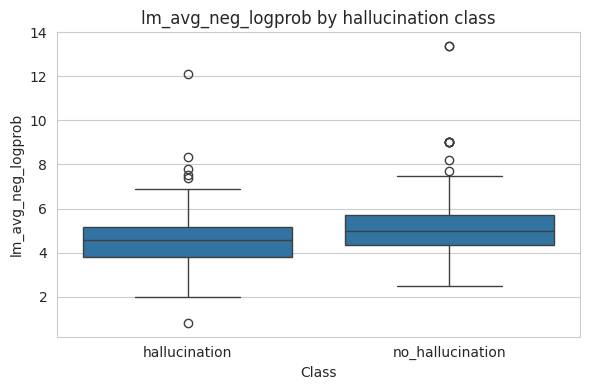

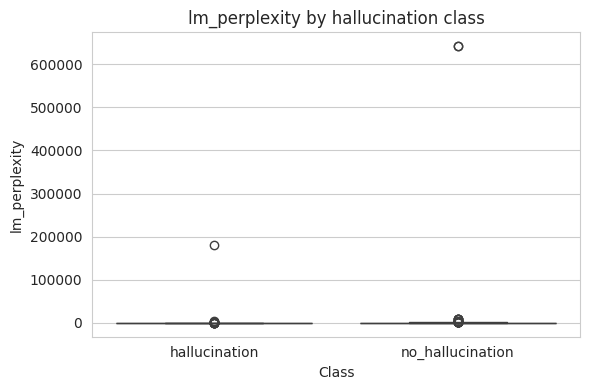

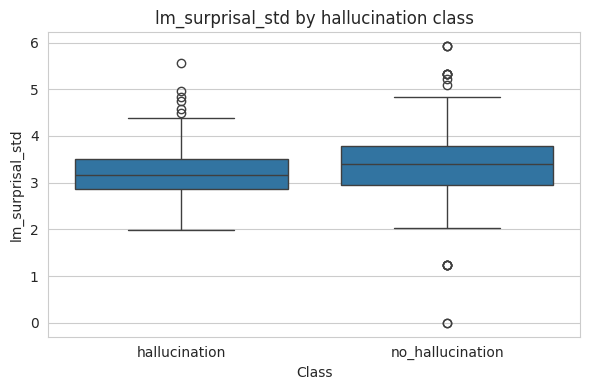

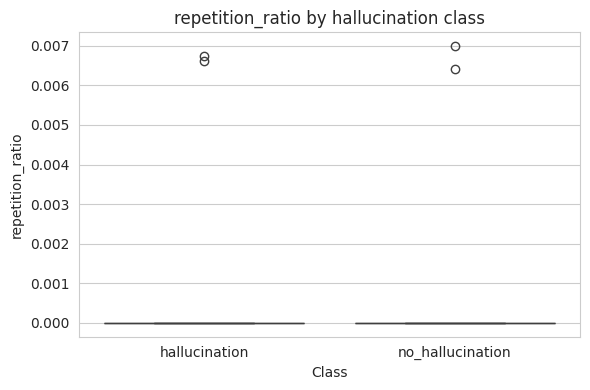

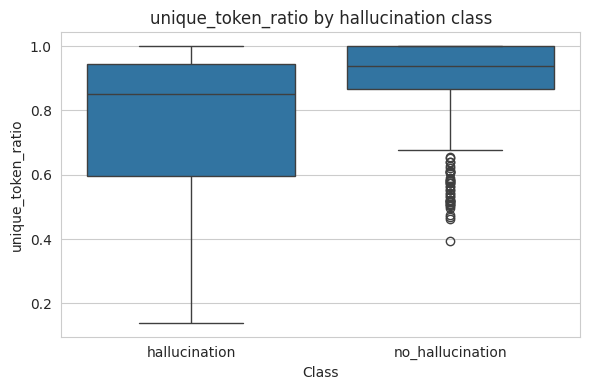

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

for col in LM_FEATURES:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=feature_df, x="hallucination_binary", y=col)
    plt.title(f"{col} by hallucination class")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 13. Build the final modeling table

At this stage we keep only the rows that:
- have valid hallucination labels
- have all required LM features for modeling

This becomes the dataset used in the ablation study.


In [14]:
model_cols = LM_FEATURES + ["y"]
model_df = feature_df[model_cols].dropna().copy()

if len(model_df) < MIN_ROWS_FOR_MODELING:
    raise ValueError("Too few rows remain after dropping missing LM feature values.")

if model_df["y"].nunique() < 2:
    raise ValueError("Modeling requires both hallucination and no_hallucination classes.")

print("Rows used for modeling:", len(model_df))
print("Class counts used for modeling:")
print(model_df["y"].value_counts())


Rows used for modeling: 665
Class counts used for modeling:
y
0    469
1    196
Name: count, dtype: int64


## 14. Define the ablation study

The purpose of the ablation study is to answer:
- which LM uncertainty feature matters most?
- are the best results driven by one dominant signal or by combining multiple signals?

We evaluate **all non-empty feature subsets** from the LM feature list.

With 5 features, this gives 31 ablations, which is comfortably above your target of at least 10.


In [15]:
from itertools import combinations

feature_sets = []
for r in range(1, len(LM_FEATURES) + 1):
    for combo in combinations(LM_FEATURES, r):
        feature_sets.append(list(combo))

print("Total ablations to run:", len(feature_sets))
feature_sets[:5]


Total ablations to run: 31


[['lm_avg_neg_logprob'],
 ['lm_perplexity'],
 ['lm_surprisal_std'],
 ['repetition_ratio'],
 ['unique_token_ratio']]

## 15. Train and evaluate all ablations

Each ablation uses:
- a stratified train-test split
- logistic regression as a simple baseline classifier
- a shared evaluation protocol across all feature subsets

Why logistic regression?
- it is lightweight and interpretable
- it gives readable coefficients
- it is a strong baseline for low-dimensional structured features


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    det_curve,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

results = []
stored_runs = {}

for features in feature_sets:
    X = model_df[features]
    y = model_df["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
    fpr_det, fnr_det, det_thresholds = det_curve(y_test, y_score)
    det_best_idx = int(np.argmin(fpr_det + fnr_det))

    name = " + ".join(features)
    row = {
        "ablation_name": name,
        "features": "|".join(features),
        "n_features": len(features),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "avg_precision": average_precision_score(y_test, y_score),
        "det_best_threshold": float(det_thresholds[det_best_idx]),
        "det_best_fpr": float(fpr_det[det_best_idx]),
        "det_best_fnr": float(fnr_det[det_best_idx]),
        "det_fpr_plus_fnr": float(fpr_det[det_best_idx] + fnr_det[det_best_idx]),
    }
    results.append(row)

    stored_runs[name] = {
        "features": features,
        "clf": clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_score": y_score,
        "fpr": fpr,
        "tpr": tpr,
        "fpr_det": fpr_det,
        "fnr_det": fnr_det,
        "det_thresholds": det_thresholds,
    }

results_df = pd.DataFrame(results).sort_values(
    ["det_fpr_plus_fnr", "roc_auc", "f1"],
    ascending=[True, False, False]
).reset_index(drop=True)

results_path = OUTPUT_DIR / "lm_ablation_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved ablation table to:", results_path.resolve())
results_df.head(15)


Saved ablation table to: /content/lm_uncertainty_outputs/lm_ablation_results.csv


,ablation_name,features,n_features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_threshold,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,lm_perplexity + unique_token_ratio,lm_perplexity|unique_token_ratio,2,0.730,0.631579,0.203390,0.307692,0.728633,0.526516,0.266192,0.326241,0.254237,0.580478
1,lm_perplexity + repetition_ratio + unique_toke...,lm_perplexity|repetition_ratio|unique_token_ratio,3,0.730,0.631579,0.203390,0.307692,0.728633,0.526516,0.266192,0.326241,0.254237,0.580478
2,unique_token_ratio,unique_token_ratio,1,0.730,0.631579,0.203390,0.307692,0.730857,0.521804,0.261832,0.333333,0.254237,0.587571
3,repetition_ratio + unique_token_ratio,repetition_ratio|unique_token_ratio,2,0.730,0.631579,0.203390,0.307692,0.730857,0.521804,0.261832,0.333333,0.254237,0.587571
4,lm_perplexity + lm_surprisal_std + unique_toke...,lm_perplexity|lm_surprisal_std|unique_token_ratio,3,0.710,0.523810,0.186441,0.275000,0.701346,0.491624,0.282480,0.241135,0.389831,0.630965
5,lm_perplexity + lm_surprisal_std + repetition_...,lm_perplexity|lm_surprisal_std|repetition_rati...,4,0.710,0.523810,0.186441,0.275000,0.701346,0.491624,0.282480,0.241135,0.389831,0.630965
6,lm_surprisal_std + unique_token_ratio,lm_surprisal_std|unique_token_ratio,2,0.715,0.550000,0.186441,0.278481,0.712165,0.500576,0.271561,0.276596,0.355932,0.632528
7,lm_surprisal_std + repetition_ratio + unique_t...,lm_surprisal_std|repetition_ratio|unique_token...,3,0.715,0.550000,0.186441,0.278481,0.712165,0.500576,0.271561,0.276596,0.355932,0.632528
8,lm_avg_neg_logprob + lm_perplexity + unique_to...,lm_avg_neg_logprob|lm_perplexity|unique_token_...,3,0.705,0.500000,0.186441,0.271605,0.691970,0.499745,0.276297,0.269504,0.406780,0.676283
9,lm_avg_neg_logprob + lm_perplexity + repetitio...,lm_avg_neg_logprob|lm_perplexity|repetition_ra...,4,0.705,0.500000,0.186441,0.271605,0.691970,0.499745,0.276297,0.269504,0.406780,0.676283


## 16. Identify the best-performing ablation

We rank ablations primarily by the DET-oriented criterion:
- smallest `FPR + FNR`

This is useful because hallucination detection is often more about operational tradeoffs than raw accuracy alone.

If multiple ablations are close, ROC AUC and F1 help break ties.


In [17]:
best_row = results_df.iloc[0]
best_name = best_row["ablation_name"]
best_features = best_row["features"].split("|")
best_run = stored_runs[best_name]

print("Best ablation:", best_name)
print("Best features:", best_features)
print(best_row)


Best ablation: lm_perplexity + unique_token_ratio
Best features: ['lm_perplexity', 'unique_token_ratio']
ablation_name         lm_perplexity + unique_token_ratio
features                lm_perplexity|unique_token_ratio
n_features                                             2
accuracy                                            0.73
precision                                       0.631579
recall                                           0.20339
f1                                              0.307692
roc_auc                                         0.728633
avg_precision                                   0.526516
det_best_threshold                              0.266192
det_best_fpr                                    0.326241
det_best_fnr                                    0.254237
det_fpr_plus_fnr                                0.580478
Name: 0, dtype: object


## 17. Compare the strongest ablations

This table makes it easier to report:
- which feature combinations worked best
- whether adding more features always helped
- whether one single LM feature was already strong on its own


In [18]:
top_cols = [
    "ablation_name",
    "n_features",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "avg_precision",
    "det_best_fpr",
    "det_best_fnr",
    "det_fpr_plus_fnr",
]

results_df[top_cols].head(15)


,ablation_name,n_features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,lm_perplexity + unique_token_ratio,2,0.730,0.631579,0.203390,0.307692,0.728633,0.526516,0.326241,0.254237,0.580478
1,lm_perplexity + repetition_ratio + unique_toke...,3,0.730,0.631579,0.203390,0.307692,0.728633,0.526516,0.326241,0.254237,0.580478
2,unique_token_ratio,1,0.730,0.631579,0.203390,0.307692,0.730857,0.521804,0.333333,0.254237,0.587571
3,repetition_ratio + unique_token_ratio,2,0.730,0.631579,0.203390,0.307692,0.730857,0.521804,0.333333,0.254237,0.587571
4,lm_perplexity + lm_surprisal_std + unique_toke...,3,0.710,0.523810,0.186441,0.275000,0.701346,0.491624,0.241135,0.389831,0.630965
5,lm_perplexity + lm_surprisal_std + repetition_...,4,0.710,0.523810,0.186441,0.275000,0.701346,0.491624,0.241135,0.389831,0.630965
6,lm_surprisal_std + unique_token_ratio,2,0.715,0.550000,0.186441,0.278481,0.712165,0.500576,0.276596,0.355932,0.632528
7,lm_surprisal_std + repetition_ratio + unique_t...,3,0.715,0.550000,0.186441,0.278481,0.712165,0.500576,0.276596,0.355932,0.632528
8,lm_avg_neg_logprob + lm_perplexity + unique_to...,3,0.705,0.500000,0.186441,0.271605,0.691970,0.499745,0.269504,0.406780,0.676283
9,lm_avg_neg_logprob + lm_perplexity + repetitio...,4,0.705,0.500000,0.186441,0.271605,0.691970,0.499745,0.269504,0.406780,0.676283


## 18. Plot ROC curves for the top ablations

These ROC curves help show how well the strongest LM-based models separate the two classes across thresholds.

Interpretation reminder:
- higher curve = better
- larger ROC AUC = better ranking ability
- the diagonal line represents chance behavior


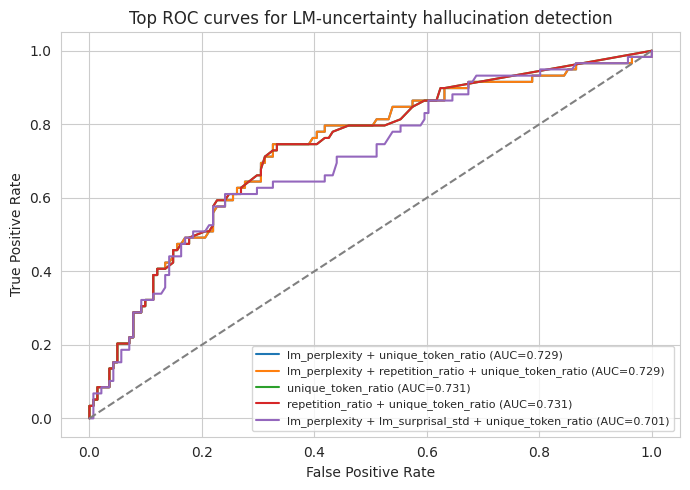

In [19]:
top_names = results_df["ablation_name"].head(5).tolist()

plt.figure(figsize=(7, 5))
for name in top_names:
    run = stored_runs[name]
    auc = roc_auc_score(run["y_test"], run["y_score"])
    plt.plot(run["fpr"], run["tpr"], label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Top ROC curves for LM-uncertainty hallucination detection")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 19. Plot DET curves for the top ablations

This is one of the most important sections for your project.

DET curves show the tradeoff between:
- false positives
- false negatives

Lower-left behavior is better.
This is especially relevant when missed hallucinations are more costly than false alarms.


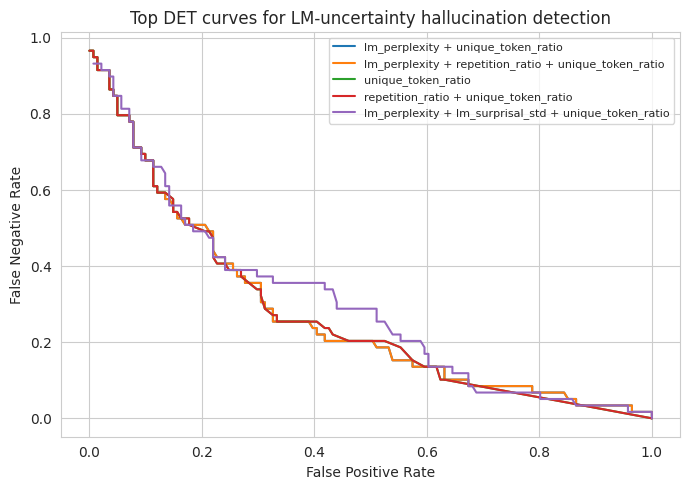

In [20]:
plt.figure(figsize=(7, 5))
for name in top_names:
    run = stored_runs[name]
    plt.plot(run["fpr_det"], run["fnr_det"], label=name)

plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("Top DET curves for LM-uncertainty hallucination detection")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 20. Evaluate the best model in detail

Now we switch from broad ablation comparison to a close look at the best-performing LM feature set.

This includes:
- confusion matrix
- classification report
- ROC AUC
- DET best operating point


In [21]:
best_y_test = best_run["y_test"]
best_y_pred = best_run["y_pred"]
best_y_score = best_run["y_score"]

cm = confusion_matrix(best_y_test, best_y_pred)

print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(best_y_test, best_y_pred, digits=4))
print("ROC AUC:", round(roc_auc_score(best_y_test, best_y_score), 4))
print("Average Precision:", round(average_precision_score(best_y_test, best_y_score), 4))
print("Best DET threshold:", round(best_row["det_best_threshold"], 4))
print("Best DET FPR:", round(best_row["det_best_fpr"], 4))
print("Best DET FNR:", round(best_row["det_best_fnr"], 4))


Confusion matrix:
[[134   7]
 [ 47  12]]

Classification report:
              precision    recall  f1-score   support

           0     0.7403    0.9504    0.8323       141
           1     0.6316    0.2034    0.3077        59

    accuracy                         0.7300       200
   macro avg     0.6860    0.5769    0.5700       200
weighted avg     0.7082    0.7300    0.6775       200

ROC AUC: 0.7286
Average Precision: 0.5265
Best DET threshold: 0.2662
Best DET FPR: 0.3262
Best DET FNR: 0.2542


## 21. Inspect feature coefficients for the best model

Because we use logistic regression, we can inspect which LM features push the detector toward:
- `hallucination`
- `no_hallucination`

This is useful for interpretation in the final report.


In [22]:
coef_df = pd.DataFrame({
    "feature": best_features,
    "coefficient": best_run["clf"].coef_[0],
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

coef_df


,feature,coefficient
0,lm_perplexity,-0.000148
1,unique_token_ratio,-2.950049


## 22. Error analysis for the best model

This section helps answer an important question:

> When the detector makes mistakes, what kind of transcripts is it confusing?

We attach the model outputs back to the original rows so you can inspect:
- false positives
- false negatives
- prediction score
- source dataset and file


In [23]:
best_feature_rows = feature_df.loc[model_df.index].copy()
inspect_df = best_feature_rows.loc[best_run["X_test"].index].copy()
inspect_df["true"] = best_y_test.values
inspect_df["pred"] = best_y_pred
inspect_df["score"] = best_y_score

mistakes_df = inspect_df[inspect_df["true"] != inspect_df["pred"]].copy()

mistakes_path = OUTPUT_DIR / "lm_best_model_mistakes.csv"
mistakes_df.to_csv(mistakes_path, index=False)

print("Saved mistakes to:", mistakes_path.resolve())
print("Mistake count:", len(mistakes_df))

cols_to_show = [
    c for c in [
        "dataset",
        "source_file",
        "sample_id",
        "label_3class",
        "hallucination_binary",
        "pred_text",
        "lm_avg_neg_logprob",
        "lm_perplexity",
        "lm_surprisal_std",
        "repetition_ratio",
        "unique_token_ratio",
        "true",
        "pred",
        "score",
    ]
    if c in mistakes_df.columns
]

mistakes_df[cols_to_show].head(20)


Saved mistakes to: /content/lm_uncertainty_outputs/lm_best_model_mistakes.csv
Mistake count: 54


,dataset,source_file,sample_id,label_3class,hallucination_binary,pred_text,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,true,pred,score
271,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0024__pink_10dB,Hallucination Error,hallucination,It is obviously unnecessary for us to point ou...,4.971661,144.266328,3.596578,0.0,0.952381,1,0,0.239226
11,adversarial,adversarial_labels (2).csv,adv_4446-2271-0005,Hallucination Error,hallucination,She saves her hands too. She had her best in t...,5.170770,176.050290,3.623422,0.0,0.866667,1,0,0.287254
60,adversarial,adversarial_labels (2).csv,adv_3575-170457-0024,Hallucination Error,hallucination,"I don't always succeed, because sometimes when...",4.073645,58.770799,3.040485,0.0,0.795455,1,0,0.335954
199,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0006__pink_10dB,Hallucination Error,hallucination,The strength that enables someone in a trance ...,5.584624,266.300085,3.337213,0.0,0.960000,1,0,0.231937
81,adversarial,adversarial_labels (2).csv,adv_4446-2273-0002,Hallucination Error,hallucination,I would care to do it without having to have a...,4.781072,119.232115,3.261306,0.0,0.928571,1,0,0.252939
38,adversarial,adversarial_labels (2).csv,adv_7021-85628-0002,Hallucination Error,hallucination,"He was sought of able, and he was on loop, and...",6.408710,607.110295,3.700771,0.0,0.833333,1,0,0.294420
57,adversarial,adversarial_labels (2).csv,adv_1188-133604-0037,Hallucination Error,hallucination,"Every morning, after every visit, even I see i...",4.818797,123.816064,3.210025,0.0,0.765957,1,0,0.353439
61,adversarial,adversarial_labels (2).csv,adv_7176-88083-0006,Hallucination Error,hallucination,It might have seen the drop of this isalaphera...,6.090128,441.477892,3.024741,0.0,1.000000,1,0,0.207304
99,adversarial,adversarial_labels (2).csv,adv_7127-75946-0028,Hallucination Error,hallucination,"I agree all his happiness, all his brilliancy,...",4.461077,86.580725,3.770861,0.0,0.750000,1,0,0.365543
58,adversarial,adversarial_labels (2).csv,adv_260-123286-0023,Hallucination Error,hallucination,The route will speed up our water mountain and...,5.445417,231.693970,3.548927,0.0,1.000000,1,0,0.212436


## 23. Save best-model predictions

This final prediction table is useful for:
- writing the report
- sharing results with teammates
- checking the model’s decisions outside the notebook


In [24]:
predictions_df = inspect_df.copy()
predictions_path = OUTPUT_DIR / "lm_best_model_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved best-model predictions to:", predictions_path.resolve())
predictions_df.head()


Saved best-model predictions to: /content/lm_uncertainty_outputs/lm_best_model_test_predictions.csv


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,...,y,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,token_count,true,pred,score
271,librispeech_fallback,ls_0024__pink_10dB,IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OU...,It is obviously unnecessary for us to point ou...,1.0,-0.163974,0.018758,1.170213,Hallucination Error,hallucination,...,1,4.971661,144.266328,3.596578,0.0,0.952381,21,1,0,0.239226
276,librispeech_fallback,ls_0025__babble_10dB,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,Nor is Mr. Quilter's matter less interesting t...,1.0,-0.330646,0.025334,1.016667,Non-Hallucination Error,no_hallucination,...,0,4.714398,111.541686,2.960218,0.0,0.866667,15,0,0,0.289206
11,adversarial,adv_4446-2271-0005,SHE SAVES HER HAND TOO SHE'S AT HER BEST IN TH...,She saves her hands too. She had her best in t...,1.0,-0.737511,0.126115,1.000000,Hallucination Error,hallucination,...,1,5.170770,176.050290,3.623422,0.0,0.866667,15,1,0,0.287254
526,librispeech,7176-88083-0006,IT MIGHT HAVE SEEMED THAT A TROUT OF THIS SIZE...,It might have seemed that a trout of this size...,1.0,-0.179689,0.001621,1.054795,No Error,no_hallucination,...,0,4.732662,113.597526,2.903868,0.0,0.937500,16,0,0,0.248149
159,commonvoice,ls_59,THE BUZZER'S WHIRR TRIGGERED HIS MUSCLES INTO ...,The buzzers were triggered his muscles into co...,1.0,-0.352458,0.006165,0.941176,Non-Hallucination Error,no_hallucination,...,0,7.151828,1276.436911,4.091929,0.0,1.000000,11,0,0,0.187792


## 24. Generate a compact markdown summary

This cell writes a simple summary file so the main findings are easy to reuse in a report or README.

The summary includes:
- dataset size
- best ablation
- key metrics
- a short interpretation


In [25]:
summary_lines = []
summary_lines.append("# LM-Uncertainty Hallucination Detection Summary")
summary_lines.append("")
summary_lines.append("## Overview")
summary_lines.append(
    "This summary reports transcript-side hallucination detection results using language-model uncertainty features."
)
summary_lines.append("")
summary_lines.append("## Data")
summary_lines.append(f"- Usable labeled rows: {len(valid_df)}")
summary_lines.append(f"- Rows with usable pred_text: {len(analysis_df)}")
summary_lines.append(f"- Rows used for modeling: {len(model_df)}")
summary_lines.append("")
summary_lines.append("## Best Ablation")
summary_lines.append(f"- Name: {best_name}")
summary_lines.append(f"- Features: {', '.join(best_features)}")
summary_lines.append(f"- Accuracy: {best_row['accuracy']:.4f}")
summary_lines.append(f"- Precision: {best_row['precision']:.4f}")
summary_lines.append(f"- Recall: {best_row['recall']:.4f}")
summary_lines.append(f"- F1: {best_row['f1']:.4f}")
summary_lines.append(f"- ROC AUC: {best_row['roc_auc']:.4f}")
summary_lines.append(f"- Average Precision: {best_row['avg_precision']:.4f}")
summary_lines.append(f"- DET best FPR: {best_row['det_best_fpr']:.4f}")
summary_lines.append(f"- DET best FNR: {best_row['det_best_fnr']:.4f}")
summary_lines.append("")
summary_lines.append("## Interpretation")
summary_lines.append(
    "- This notebook tests whether hallucinated transcripts look unusually uncertain from the perspective of a text language model."
)
summary_lines.append(
    "- Strong performance would suggest that transcript-only uncertainty contains useful signal, even without directly reusing ASR confidence features."
)
summary_lines.append(
    "- However, this remains an indirect detector because it does not directly compare transcript content against the audio during inference."
)

summary_text = "\n".join(summary_lines)
summary_path = OUTPUT_DIR / "lm_uncertainty_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print("Saved summary to:", summary_path.resolve())
print()
print(summary_text)


Saved summary to: /content/lm_uncertainty_outputs/lm_uncertainty_summary.md

# LM-Uncertainty Hallucination Detection Summary

## Overview
This summary reports transcript-side hallucination detection results using language-model uncertainty features.

## Data
- Usable labeled rows: 665
- Rows with usable pred_text: 665
- Rows used for modeling: 665

## Best Ablation
- Name: lm_perplexity + unique_token_ratio
- Features: lm_perplexity, unique_token_ratio
- Accuracy: 0.7300
- Precision: 0.6316
- Recall: 0.2034
- F1: 0.3077
- ROC AUC: 0.7286
- Average Precision: 0.5265
- DET best FPR: 0.3262
- DET best FNR: 0.2542

## Interpretation
- This notebook tests whether hallucinated transcripts look unusually uncertain from the perspective of a text language model.
- Strong performance would suggest that transcript-only uncertainty contains useful signal, even without directly reusing ASR confidence features.
- However, this remains an indirect detector because it does not directly compare transc

## 25. Final notes for readers

How to interpret this notebook in the project:

- If this LM-based detector performs well, it means transcript-side uncertainty is a useful hallucination signal.
- If it performs worse than the ASR-confidence notebook, that suggests the stronger signal comes from Whisper’s internal uncertainty rather than transcript fluency alone.
- If both perform well, that gives you two complementary baselines for the final report.

This makes the notebook useful not only as a model, but also as a comparison study.
